In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [5]:
df.info

<bound method DataFrame.info of       CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   

In [6]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [7]:
df.isnull().sum()/len(df) * 100 

CustomerID            0.000000
Count                 0.000000
Country               0.000000
State                 0.000000
City                  0.000000
Zip Code              0.000000
Lat Long              0.000000
Latitude              0.000000
Longitude             0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Multiple Lines        0.000000
Internet Service      0.000000
Online Security       0.000000
Online Backup         0.000000
Device Protection     0.000000
Tech Support          0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Contract              0.000000
Paperless Billing     0.000000
Payment Method        0.000000
Monthly Charges       0.000000
Total Charges         0.000000
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV                  0.000000
Churn Re

In [8]:
# Checking for duplicate rows
# Result: 0 duplicates found - data is clean, no rows need to be removed
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [10]:
# Key findings from descriptive statistics:
# - 27% churn rate meaning the company loses roughly 1 in 4 customers
# - Average customer pays $64.76/month, so losing 27% of 7043 customers
# - 1,900 customers are leaving, loosing roughly $123,000 per month and  roughly $1.47 million per year in lost revenue
#   represents significant monthly revenue loss
# - New customers (low tenure) appear most at risk based on the distribution
# - CLTV ranges widely suggesting some customers are far more valuable to retain

In [11]:
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

In [12]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [13]:
df['Churn Label'].value_counts(normalize = True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [14]:
df.sample(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
4932,2465-BLLEU,1,United States,California,Salinas,93906,"36.722898, -121.633648",36.722898,-121.633648,Male,...,Month-to-month,Yes,Mailed check,19.75,19.75,No,0,33,4441,NaN
6316,0708-LGSMF,1,United States,California,Milpitas,95035,"37.441931, -121.878502",37.441931,-121.878502,Male,...,Month-to-month,Yes,Electronic check,65.85,902.25,No,0,44,2731,NaN
6367,1228-ZLNBX,1,United States,California,Farmington,95230,"37.956963, -120.863055",37.956963,-120.863055,Male,...,Month-to-month,No,Mailed check,75.30,1570.7,No,0,50,2847,NaN
1104,3683-QKIUE,1,United States,California,San Francisco,94107,"37.768881, -122.395521",37.768881,-122.395521,Female,...,Month-to-month,Yes,Bank transfer (automatic),50.80,288.05,Yes,1,88,4713,Competitor offered higher download speeds
6836,2144-ESWKO,1,United States,California,San Pedro,90732,"33.744119, -118.31448",33.744119,-118.314480,Male,...,One year,Yes,Credit card (automatic),35.20,1463.7,No,0,70,5268,NaN
6071,8903-XEBGX,1,United States,California,Lancaster,93534,"34.727529, -118.153098",34.727529,-118.153098,Male,...,Month-to-month,Yes,Electronic check,55.30,108.65,No,0,67,4594,NaN
4034,8059-UDZFY,1,United States,California,Lucerne,95458,"39.141934, -122.770679",39.141934,-122.770679,Female,...,Month-to-month,Yes,Bank transfer (automatic),105.35,3465.05,No,0,58,4738,NaN
2854,3733-LSYCE,1,United States,California,Samoa,95564,"40.809636, -124.189977",40.809636,-124.189977,Female,...,Month-to-month,No,Bank transfer (automatic),75.35,1114.55,No,0,67,4891,NaN
1440,6289-CPNLD,1,United States,California,Temecula,92591,"33.540604, -117.10909",33.540604,-117.109090,Male,...,One year,Yes,Mailed check,73.90,2405.05,Yes,1,73,5374,Attitude of service provider
587,2528-HFYZX,1,United States,California,Santa Ana,92706,"33.765893, -117.881533",33.765893,-117.881533,Male,...,Month-to-month,Yes,Electronic check,76.45,1233.4,Yes,1,92,3266,Attitude of support person


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [16]:
# Total Charges is stored as text (object) but should be a number
# We convert it to float64 so our model can use it
# errors='coerce' means if it finds any weird values it converts them to NaN instead of crashing
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [17]:
df['Total Charges'].dtype

dtype('float64')

In [18]:
# Checking if the conversion created any missing values
df['Total Charges'].isnull().sum()

np.int64(11)

In [19]:
# Churn Reason only has values for customers who actually churned
# The rest are NaN which makes complete sense
# We will fill the missing values with 'No Churn' so it's clear
df['Churn Reason'] = df['Churn Reason'].fillna('No Churn')

In [20]:
df['Churn Reason'].isnull().sum()

np.int64(0)

In [21]:
df[df['Total Charges'].isnull()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,No Churn
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,No Churn
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,No Churn
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,No Churn
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,No Churn
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,No Churn
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,No Churn
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,No Churn
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,No Churn
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,No Churn


In [22]:
# 11 rows have missing Total Charges values
# Investigation showed these are legitimate customers on long term contracts
# with no obvious reason for missing charges - likely a data entry error
# Since this represents only 0.15% of data we drop these rows
# Filling with median was rejected because inserting fake financial 
# figures could mislead the model
df = df.dropna(subset=['Total Charges'])

In [23]:
df.shape

(7032, 33)

In [24]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [25]:
df.shape

(7032, 33)

In [26]:
df['Total Charges'].dtype

dtype('float64')

In [27]:
# Verifying that missing Churn Reason belongs only to customers who did NOT churn
df[df['Churn Reason'].isnull()]['Churn Label'].value_counts()

Series([], Name: count, dtype: int64)

In [28]:
df['Churn Reason'].isnull().sum()

np.int64(0)

In [29]:
df['Churn Reason'].value_counts()

Churn Reason
No Churn                                     5163
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Lack of affordable download/upload speed       44
Long distance charges                          44
Limited range of services                      44
Poor expertise of phone support                20
Poor expertise of online support     

In [30]:
# CHURN REASON ANALYSIS - Key Business Findings
# Total churned customers: 1869

# FINDING 1 - Competitor threat is the largest category
# 621 customers (33% of churned) left for a competitor
# This suggests the company needs to conduct competitive analysis
# and potentially improve their product offerings and pricing

# FINDING 2 - Customer service attitude is the single biggest individual reason
# 327 customers left due to poor attitude of staff
# This is actionable - the company should invest in customer service training
# and potentially review their support staff performance metrics

# FINDING 3 - Price sensitivity affects 199 customers
# The company should consider loyalty discounts or flexible pricing
# especially for customers showing early churn signals

# FINDING 4 - Only 6 customers are marked as Deceased
# These are legitimate churns that cannot be prevented
# In a real model we might want to exclude these from training data
# as they represent a different type of churn entirely

In [31]:
# Dropping columns that add no predictive value to our model
# Reasons documented in Feature Selection Reasoning section above

df = df.drop(columns=[
    'CustomerID',    # unique identifier, no predictive value
    'Count',         # every value is 1, zero variation
    'Country',       # every value is United States, zero variation
    'State',         # every value is California, zero variation
    'Lat Long',      # redundant, already have Latitude and Longitude separately
    'City',          # too many unique values, high cardinality
    'Zip Code'       # too many unique values, high cardinality
])

In [32]:
df.shape

(7032, 26)

In [33]:
df.columns.tolist()

['Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [34]:
# Dropping columns that would cause data leakage
# Churn Score and Churn Reason are only known AFTER churn occurs
# so they cannot be used to PREDICT future churn
# Churn Label is redundant as Churn Value already captures this as 0/1

df = df.drop(columns=[
    'Churn Score',    
    'Churn Reason',   
    'Churn Label'     
])

In [35]:
df.shape

(7032, 23)

In [36]:
df.columns.tolist()

['Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'CLTV']

In [37]:
# Final data quality check before moving to analysis
df.isnull().sum()

Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
CLTV                 0
dtype: int64

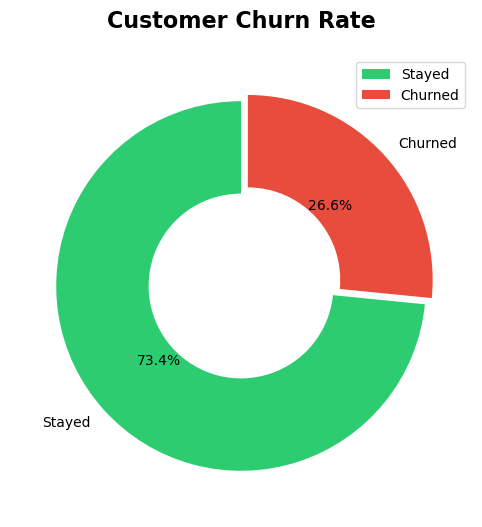

In [38]:
# Visualizing overall churn rate as a donut chart
# Donut charts are more visually appealing and commonly used in business dashboards

churn_counts = df['Churn Value'].value_counts()
labels = ['Stayed', 'Churned']
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.05)  # slightly separate the churned slice to highlight it

plt.figure(figsize=(8,6))
plt.pie(churn_counts, 
        labels=labels, 
        colors=colors,
        explode=explode,
        autopct='%1.1f%%',  # shows percentage inside each slice
        startangle=90,
        wedgeprops=dict(width=0.5))  # this makes it a donut instead of pie

plt.title('Customer Churn Rate', fontsize=16, fontweight='bold', pad=20)
plt.legend(['Stayed', 'Churned'], loc='upper right')
plt.show()

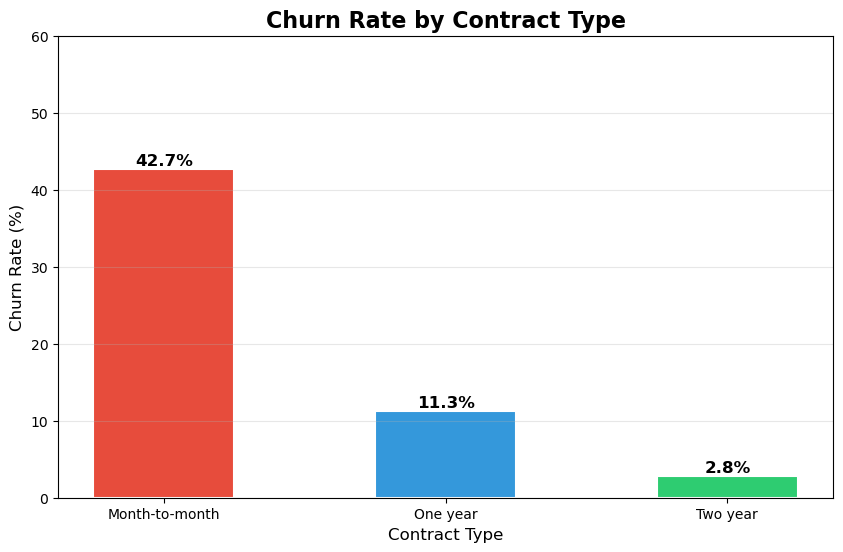

In [39]:
# Analyzing churn rate by contract type
# Hypothesis: month to month customers are more likely to churn
# because they have no long term commitment

contract_churn = df.groupby('Contract')['Churn Value'].mean() * 100

plt.figure(figsize=(10,6))
bars = plt.bar(contract_churn.index, 
               contract_churn.values,
               color=['#e74c3c','#3498db','#2ecc71'],
               width=0.5,
               edgecolor='white',
               linewidth=1.5)

# Adding percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom',
             fontweight='bold', fontsize=12)

plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 60)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [40]:
# KEY BUSINESS INSIGHT - Contract Type is a Major Churn Driver
# 
# Month to Month:  42.7% churn rate
# One Year:        11.3% churn rate  
# Two Year:         2.8% churn rate
#
# A month to month customer is 15x more likely to churn than
# a two year contract customer (42.7% vs 2.8%)
#
# BUSINESS RECOMMENDATION:
# The company should aggressively incentivize customers to upgrade
# from month to month to longer term contracts
# Even moving a customer from month to month to one year contracts
# would reduce their churn probability by 73%
# (42.7% down to 11.3%)
#
# This is especially important for NEW customers in their first 
# 3 months who are still deciding whether to stay
# Reduction = (Original - New) / Original * 100
# Reduction = (42.7 - 11.3) / 42.7 * 100
# Reduction = 31.4 / 42.7 * 100
# Reduction = 73.5%

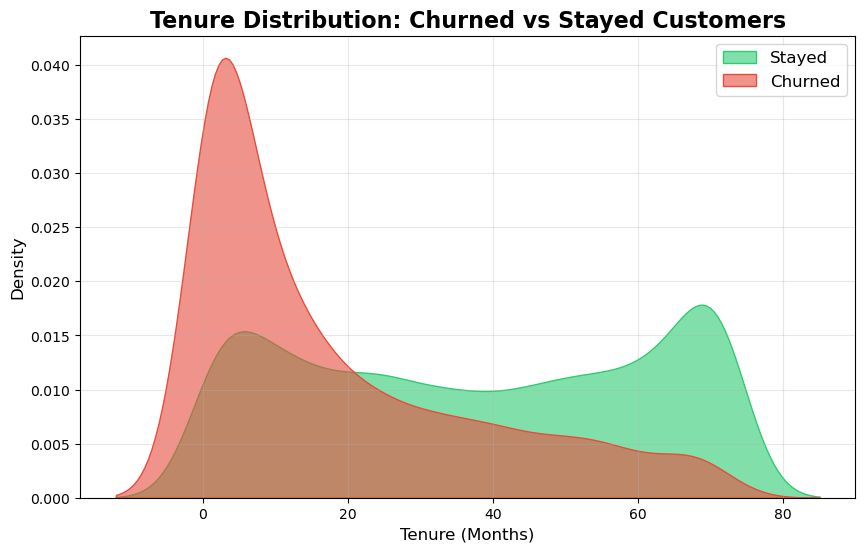

In [41]:
# Analyzing relationship between tenure and churn
# Hypothesis: newer customers churn more than long term customers
# KDE plot shows the distribution of tenure for churned vs stayed customers

plt.figure(figsize=(10,6))

sns.kdeplot(data=df[df['Churn Value']==0]['Tenure Months'], 
            fill=True,   # updated from shade=True
            color='#2ecc71', 
            label='Stayed',
            alpha=0.6)

sns.kdeplot(data=df[df['Churn Value']==1]['Tenure Months'], 
            fill=True,   # updated from shade=True
            color='#e74c3c', 
            label='Churned',
            alpha=0.6)

plt.title('Tenure Distribution: Churned vs Stayed Customers', 
          fontsize=16, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [42]:
# KEY INSIGHT - Tenure is a Strong Churn Predictor
#
# Churned customers (red): heavily concentrated in early months
# Stayed customers (green): spread across longer tenure periods
#
# This confirms our hypothesis - newer customers are significantly
# more likely to churn than long term customers
#
# The overlapping region tells us tenure alone is not enough
# to predict churn - we need multiple variables working together
# which is exactly why we are building a machine learning model
# rather than just using a simple rule like "flag all customers
# under 12 months"
#
# BUSINESS RECOMMENDATION:
# The company should have a dedicated onboarding program for
# customers in their first 6 months as this is the highest
# risk period for churn

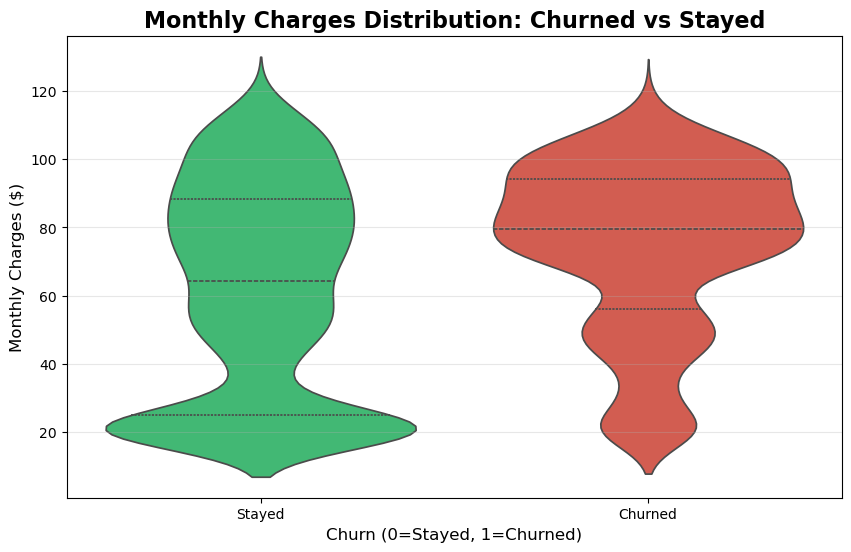

In [43]:
plt.figure(figsize=(10,6))

sns.violinplot(x='Churn Value', 
               y='Monthly Charges',
               data=df,
               hue='Churn Value',  # moved palette assignment to hue
               palette=['#2ecc71','#e74c3c'],
               inner='quartile',
               legend=False)  # hides the extra legend that hue creates

plt.title('Monthly Charges Distribution: Churned vs Stayed', 
          fontsize=16, fontweight='bold')
plt.xlabel('Churn (0=Stayed, 1=Churned)', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.grid(axis='y', alpha=0.3)
plt.show()

In [44]:
# KEY INSIGHT - Higher Monthly Charges Drive Churn
#
# Stayed customers: widest distribution at $20/month
# Churned customers: widest distribution at $80/month
#
# Customers paying premium prices are significantly more likely
# to churn than customers on basic affordable plans
#
# This connects with our Churn Reason analysis where:
# - Price too high accounted for 98 churned customers
# - Extra data charges accounted for 57 churned customers
# - Competitor made better offer accounted for 140 customers
# meaning competitors are likely offering similar services cheaper
#
# BUSINESS RECOMMENDATION:
# The company should consider two strategies:
# 1. RETENTION DISCOUNTS - proactively offer price reductions
#    to high paying month to month customers before they churn
# 2. VALUE COMMUNICATION - better communicate to premium customers
#    what they are getting for their $80/month to justify the price
#    because perception of value is just as important as actual value
#
# This insight alone could save the company significant revenue
# by targeting the right customers with the right intervention

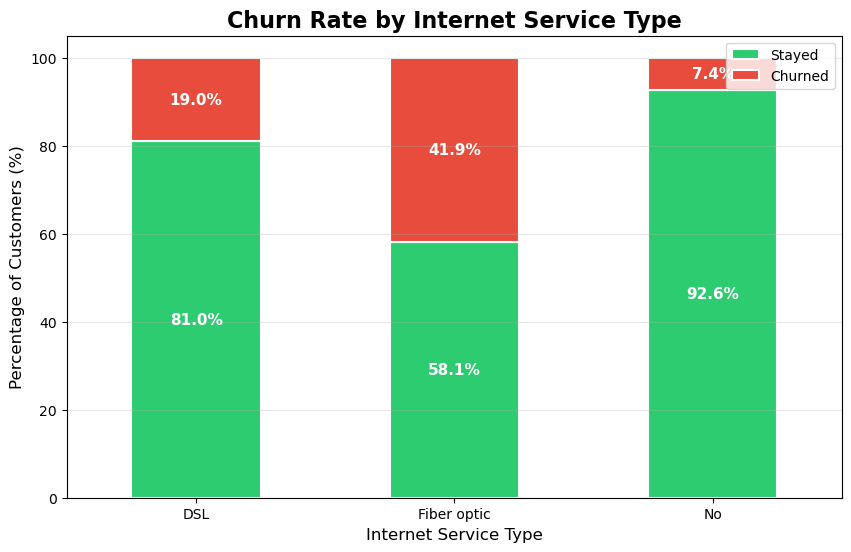

In [45]:
# Analyzing churn rate by internet service type
# Hypothesis: fiber optic customers may churn more due to higher costs

internet_churn = df.groupby('Internet Service')['Churn Value'].value_counts(normalize=True).mul(100).round(1).unstack()

ax = internet_churn.plot(kind='bar', 
                    stacked=True,
                    color=['#2ecc71','#e74c3c'],
                    edgecolor='white',
                    linewidth=1.5,
                    figsize=(10,6))

# Adding percentage labels inside each bar
for x in ax.patches:
    ax.text(x.get_x() + x.get_width()/2,
             x.get_y() + x.get_height()/2,
             f'{x.get_height():.1f}%',
             ha='center',
             va='center',
             color='white',
             fontweight='bold',
             fontsize=11)

ax.set_title('Churn Rate by Internet Service Type',
          fontsize=16, fontweight='bold')
ax.set_xlabel('Internet Service Type', fontsize=12)
ax.set_ylabel('Percentage of Customers (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Stayed', 'Churned'], loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [46]:
# KEY INSIGHT - Fiber Optic Customers Churn at Alarming Rates
#
# No Internet:  7.4% churn rate
# DSL:          19.0% churn rate
# Fiber Optic:  41.9% churn rate
#
# Fiber Optic customers are 5.6x more likely to churn than
# customers with no internet service (41.9% vs 7.4%)
#
# CRITICAL CONNECTION ACROSS CHARTS:
# Fiber Optic churn rate (41.9%) is almost identical to
# Month to Month contract churn rate (42.7%) from Chart 2
# This strongly suggests these are overlapping customer groups
# High paying fiber optic customers on flexible contracts
# represent the highest risk segment in the entire dataset
#
# HIGH RISK CUSTOMER PROFILE EMERGING:
# A customer who is BOTH on Fiber Optic AND Month to Month
# contract is extremely likely to churn
# This profile should be the PRIMARY target for retention efforts
#
# BUSINESS RECOMMENDATION:
# Salesforce type CRM systems are built exactly for this use case
# The company should create an automated alert in their CRM that
# flags any Fiber Optic + Month to Month customer who has been
# with the company less than 12 months for immediate outreach
# This is a highly actionable and specific recommendation

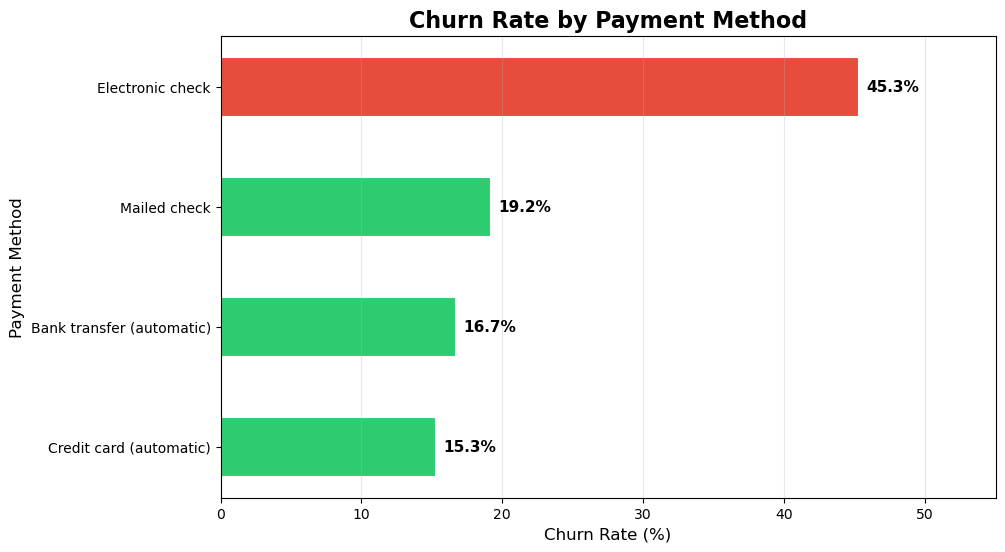

In [47]:
# Analyzing churn rate by payment method
# Hypothesis: customers on manual payment methods may churn more
# because automatic payments create friction to leave

payment_churn = df.groupby('Payment Method')['Churn Value'].mean().mul(100).round(1).sort_values(ascending=True)

plt.figure(figsize=(10,6))
bars = plt.barh(payment_churn.index,
                payment_churn.values,
                color=['#2ecc71' if x < 20 else '#e74c3c' for x in payment_churn.values],
                edgecolor='white',
                linewidth=1.5,
                height=0.5)

# Adding percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5,
             bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             ha='left',
             va='center',
             fontweight='bold',
             fontsize=11)

plt.title('Churn Rate by Payment Method',
          fontsize=16, fontweight='bold')
plt.xlabel('Churn Rate (%)', fontsize=12)
plt.ylabel('Payment Method', fontsize=12)
plt.xlim(0, 55)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [48]:
# KEY INSIGHT - Payment Method is a Strong Churn Predictor
#
# Electronic Check:       45.3% churn rate  ← DANGER ZONE
# Mailed Check:           19.2% churn rate
# Bank Transfer Auto:     16.7% churn rate
# Credit Card Auto:       15.3% churn rate
#
# CRITICAL FINDING:
# Automatic payment customers (Bank Transfer + Credit Card)
# churn at roughly 16% while manual payment customers
# churn at much higher rates
#
# WHY AUTOMATIC PAYMENTS REDUCE CHURN:
# When a customer sets up automatic payments they create
# psychological and practical friction to leaving
# Cancelling requires actively going in and stopping payments
# This extra step alone reduces impulsive cancellations
#
# WHY ELECTRONIC CHECK IS SO MUCH HIGHER THAN MAILED CHECK:
# Electronic check customers are likely younger and tech savvy
# They are comfortable researching competitors and switching online
# Mailed check customers are likely older long term customers
# who are creatures of habit and less likely to switch
#
# CONNECTION TO PREVIOUS FINDINGS:
# Electronic Check + Fiber Optic + Month to Month contract
# represents the absolute highest risk customer profile
# These three factors together likely predict churn with
# ve

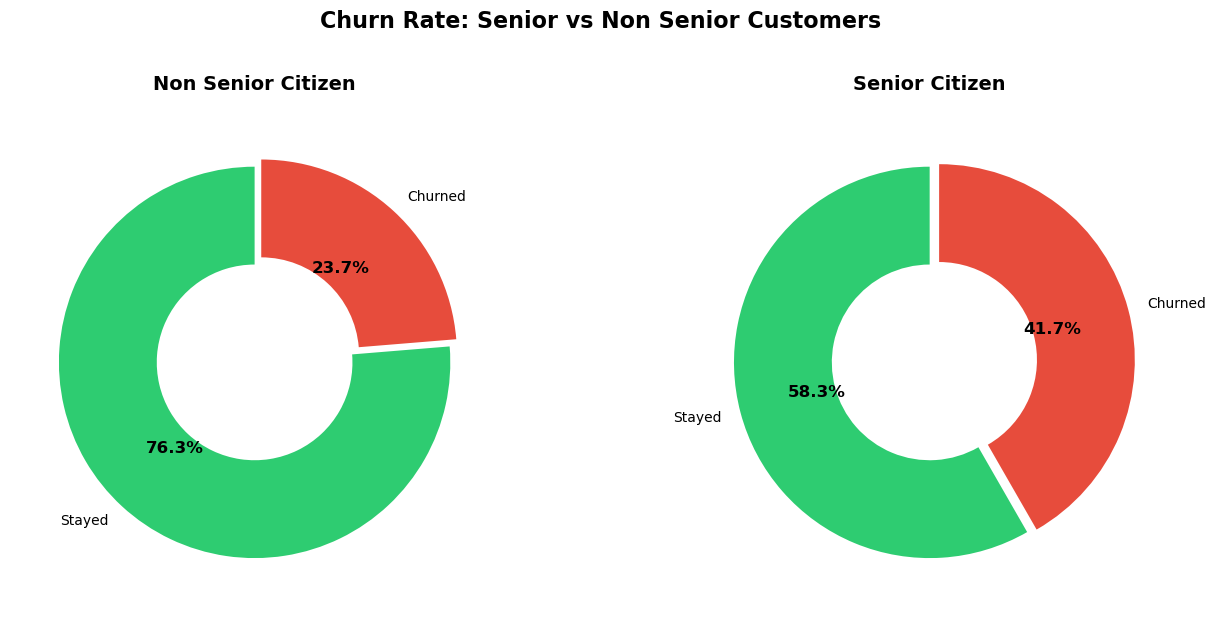

In [49]:
# Analyzing churn rate by senior citizen status
# Hypothesis: senior citizens may churn differently due to
# different tech comfort levels and service needs

senior_churn = df.groupby('Senior Citizen')['Churn Value'].value_counts(normalize=True).mul(100).round(1).unstack()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

colors = ['#2ecc71','#e74c3c']
labels = ['Stayed', 'Churned']
titles = ['Non Senior Citizen', 'Senior Citizen']

for idx, ax in enumerate(axes):
    wedges, texts, autotexts = ax.pie(
        senior_churn.iloc[idx],
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.5),
        explode=(0, 0.05)
    )
    
    # Making percentage text bold and larger
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)
    
    ax.set_title(titles[idx], 
                fontsize=14, 
                fontweight='bold',
                pad=20)

fig.suptitle('Churn Rate: Senior vs Non Senior Customers',
             fontsize=16,
             fontweight='bold',
             y=1.02)

plt.tight_layout()
plt.show()

In [50]:
# KEY INSIGHT - Senior Citizens Churn at Nearly Double the Rate
#
# Non Senior Citizens:  23.7% churn rate
# Senior Citizens:      41.7% churn rate
#
# Senior citizens are 1.76x more likely to churn than
# non senior citizens (41.7% vs 23.7%)
#
# POSSIBLE EXPLANATIONS:
# 1. FIXED INCOME PRESSURE
#    Senior citizens on fixed retirement incomes are more
#    price sensitive and likely to cut expenses when feeling
#    they are not getting sufficient value for money
#
# 2. TECH SUPPORT FRUSTRATION  
#    Senior citizens may require more patient technical support
#    Our churn reason analysis showed 192 customers left due to
#    attitude of support person - if staff are impatient with
#    senior customers this could be a major driver
#
# 3. COMPETITOR TARGETING
#    Competitors may offer senior specific discount plans
#    making it attractive for this segment to switch
#
# COMPLETE HIGH RISK CUSTOMER PROFILE:
# After 7 charts we can now define the highest risk customer:
# - Senior Citizen
# - On Fiber Optic internet
# - On Month to Month contract
# - Paying high monthly charges ($80+)
# - Using Electronic Check payment
# - Low tenure (under 12 months)
# A customer matching all these criteria is extremely likely to churn
#
# BUSINESS RECOMMENDATION:
# Create a SENIOR CITIZEN LOYALTY PROGRAM that specifically:
# 1. Offers dedicated patient tech support for senior customers
# 2. Provides senior discount pricing to compete with rivals
# 3. Incentivizes senior customers to switch to automatic payments
# 4. Offers special contract upgrade deals for senior customers
#    on month to month plans
#
# This is a specific actionable recommendation that directly
# addresses the unique needs of the highest risk segment

In [51]:
# Converting remaining text columns to numbers for correlation analysis
# This is called label encoding - replacing text categories with numbers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Create a copy so we don't mess up our original cleaned dataframe
df_encoded = df.copy()

# Encode all text columns
text_columns = df_encoded.select_dtypes(include='object').columns
for col in text_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

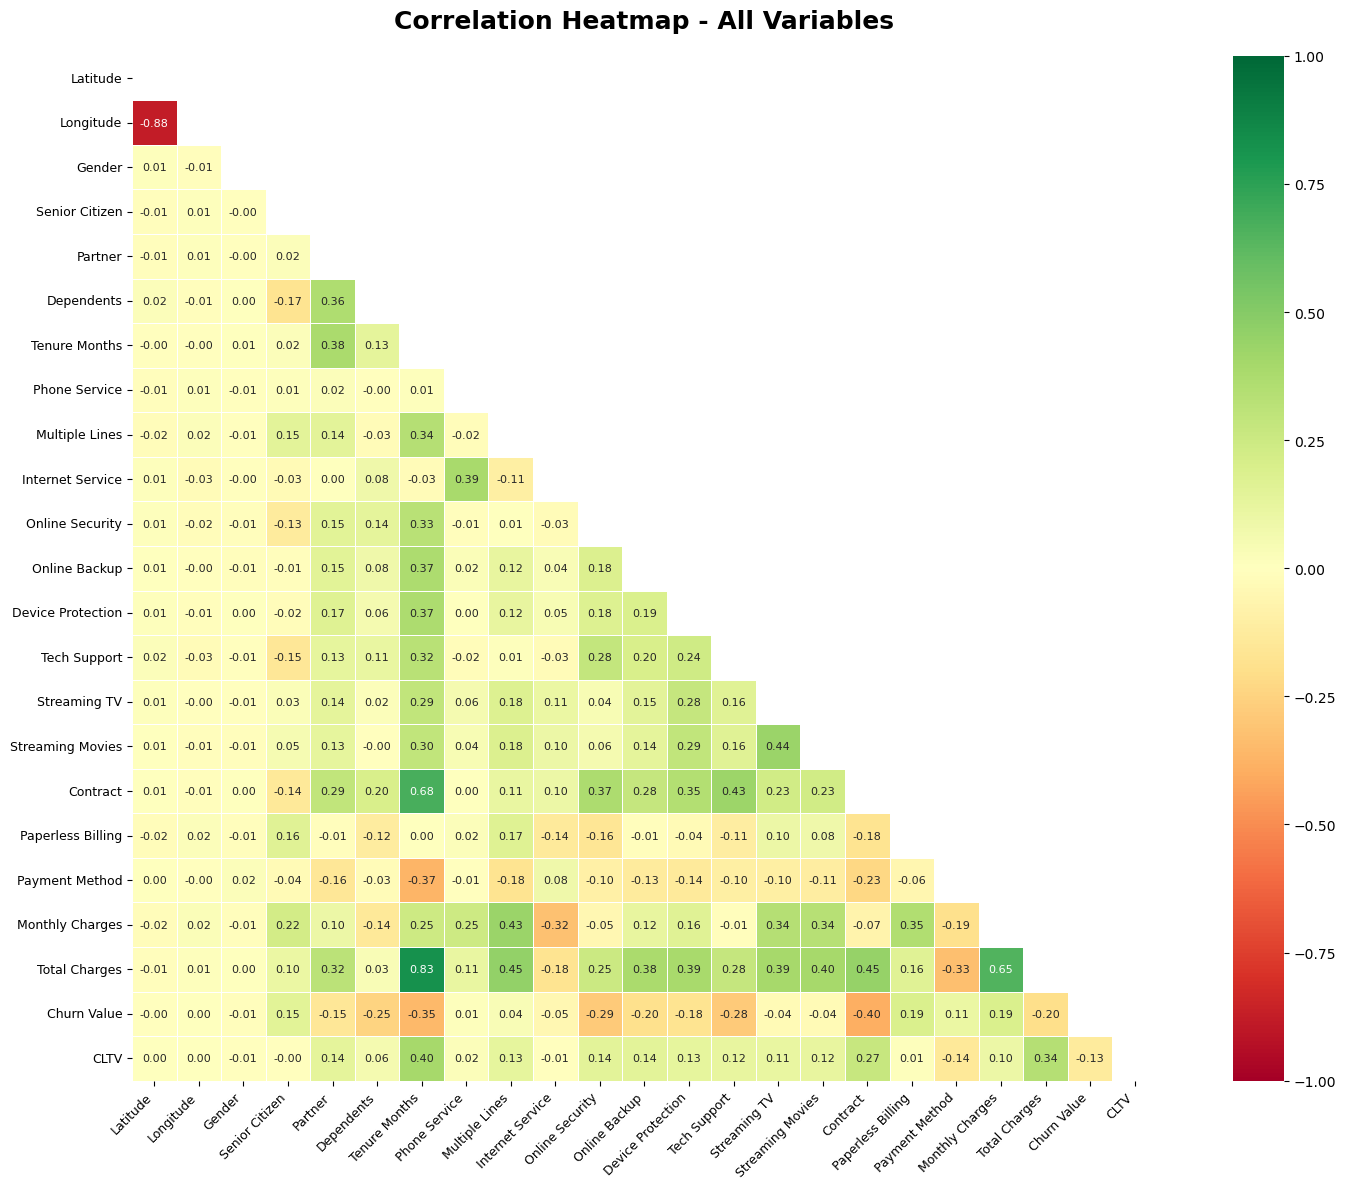

In [52]:
# Correlation heatmap showing relationships between all variables
# Correlation ranges from -1 to 1
# Close to 1 = strong positive relationship
# Close to -1 = strong negative relationship  
# Close to 0 = no relationship

plt.figure(figsize=(16,12))

# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

# Create mask to hide the upper triangle (it's a mirror image so redundant)
import numpy as np
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,           # shows numbers inside each cell
            fmt='.2f',            # rounds to 2 decimal places
            cmap='RdYlGn',        # red=negative, yellow=neutral, green=positive
            center=0,             # centers color scale at 0
            square=True,          # makes cells square not rectangular
            linewidths=0.5,       # adds thin lines between cells
            annot_kws={'size': 8},# makes annotation text smaller to fit
            vmin=-1,              # sets minimum of color scale
            vmax=1)               # sets maximum of color scale

plt.title('Correlation Heatmap - All Variables',
          fontsize=18,
          fontweight='bold',
          pad=20)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [53]:
# Finding the strongest correlations with Contract column
correlation_matrix['Contract'].sort_values(ascending=False)

Contract             1.000000
Tenure Months        0.676734
Total Charges        0.450306
Tech Support         0.425072
Online Security      0.373980
Device Protection    0.350067
Partner              0.294094
Online Backup        0.280617
CLTV                 0.269025
Streaming Movies     0.232478
Streaming TV         0.226826
Dependents           0.200931
Multiple Lines       0.111029
Internet Service     0.099579
Latitude             0.005217
Phone Service        0.003019
Gender               0.000095
Longitude           -0.011748
Monthly Charges     -0.072739
Senior Citizen      -0.141820
Paperless Billing   -0.175475
Payment Method      -0.229636
Churn Value         -0.396150
Name: Contract, dtype: float64

In [54]:
# CORRECTED INTERPRETATION - Contract Column Correlations
#
# Contract and Tenure Months:  0.68  strongest relationship
# Longer contracts = longer tenure, completely logical
# Customers on 2 year contracts are committed and stay longer
#
# Contract and Churn Value:   -0.40  strongest churn predictor
# This is stronger than initially read from the heatmap
# Contract type is the NUMBER ONE predictor of churn
# in our entire dataset
#
# Contract and Tech Support:   0.43
# Longer term customers invest more in additional services
# They are more embedded in the ecosystem making it
# harder and less likely for them to leave

In [55]:
# Looking at correlation with Churn Value specifically
# Sorted from highest to lowest so we can read it clearly
correlation_matrix['Churn Value'].sort_values(ascending=False)

Churn Value          1.000000
Monthly Charges      0.192858
Paperless Billing    0.191454
Senior Citizen       0.150541
Payment Method       0.107852
Multiple Lines       0.038043
Phone Service        0.011691
Longitude            0.004693
Latitude            -0.003600
Gender              -0.008545
Streaming TV        -0.036303
Streaming Movies    -0.038802
Internet Service    -0.047097
CLTV                -0.128253
Partner             -0.149982
Device Protection   -0.177883
Online Backup       -0.195290
Total Charges       -0.199484
Dependents          -0.248140
Tech Support        -0.282232
Online Security     -0.289050
Tenure Months       -0.354049
Contract            -0.396150
Name: Churn Value, dtype: float64

In [56]:
# FINAL CORRELATION ANALYSIS - Churn Value Predictors Ranked
#
# TOP PREDICTORS OF CHURN (most important to least important):
#
# 1. Contract:         -0.40  STRONGEST - longer contract = less churn
# 2. Tenure Months:   -0.35  longer customers = less churn  
# 3. Online Security: -0.29  security addon = less churn
# 4. Tech Support:    -0.28  support addon = less churn
# 5. Dependents:      -0.25  family customers = less churn
# 6. Monthly Charges:  0.19  higher charges = more churn
# 7. Paperless Billing:0.19  tech savvy = more churn (switching easier)
# 8. Senior Citizen:   0.15  seniors = more churn
#
# VARIABLES WITH NO PREDICTIVE VALUE:
# Gender:    -0.008  completely irrelevant to churn
# Latitude:  -0.003  location irrelevant to churn
# Longitude:  0.004  location irrelevant to churn
#
# KEY INSIGHT - SWITCHING COST THEORY:
# Online Security (-0.29) and Tech Support (-0.28) being strong
# negative predictors reveals something powerful
# Customers who use MORE services are harder to lose
# because switching means losing multiple services they depend on
# This is called SWITCHING COST in business strategy
#
# BUSINESS RECOMMENDATION BASED ON SWITCHING COST THEORY:
# The company should actively cross sell addons like:
# Online Security, Tech Support, Online Backup, Device Protection
# to high risk customers (month to month, high charges, low tenure)
# Getting them to adopt even ONE additional service significantly
# reduces their probability of churning
# This is a low cost high impact retention strategy
#
# VARIABLES TO EXCLUDE FROM MODEL:
# Gender, Latitude and Longitude show near zero correlation
# Including them would add noise without adding predictive value
# We will drop these before building our model

In [57]:
# Dropping variables with near zero correlation to Churn Value
# Gender:    -0.008  no relationship with churn
# Latitude:  -0.003  no relationship with churn
# Longitude:  0.004  no relationship with churn
# Including these would only add noise to our model

df = df.drop(columns=['Gender', 'Latitude', 'Longitude'])

In [58]:
df.shape

(7032, 20)

In [59]:
df.columns.tolist()

['Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'CLTV']

In [60]:
# Checking which columns are still text (object type)
df.select_dtypes(include='object').columns.tolist()

['Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [61]:
# Converting all text columns to numbers using One Hot Encoding
# drop_first=True removes one column from each group to avoid redundancy
# For example Contract becomes 2 columns instead of 3
# Month-to-month is represented by both One year and Two year being 0

df_model = pd.get_dummies(df, drop_first=True)

In [62]:
df_model.shape

(7032, 31)

In [63]:
df_model.columns.tolist()

['Tenure Months',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'CLTV',
 'Senior Citizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'Phone Service_Yes',
 'Multiple Lines_No phone service',
 'Multiple Lines_Yes',
 'Internet Service_Fiber optic',
 'Internet Service_No',
 'Online Security_No internet service',
 'Online Security_Yes',
 'Online Backup_No internet service',
 'Online Backup_Yes',
 'Device Protection_No internet service',
 'Device Protection_Yes',
 'Tech Support_No internet service',
 'Tech Support_Yes',
 'Streaming TV_No internet service',
 'Streaming TV_Yes',
 'Streaming Movies_No internet service',
 'Streaming Movies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'Paperless Billing_Yes',
 'Payment Method_Credit card (automatic)',
 'Payment Method_Electronic check',
 'Payment Method_Mailed check']

In [64]:
# Separating features (X) from target (y)
# X is everything the model uses to make predictions
# y is what the model is trying to predict (Churn Value)

X = df_model.drop('Churn Value', axis=1)
y = df_model['Churn Value']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 30)
Target shape: (7032,)


In [65]:
from sklearn.model_selection import train_test_split

# 80% of data for training, 20% for testing
# random_state=42 ensures we get same split every time we run
# stratify=y ensures both sets have same proportion of churned customers

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42,
                                                      stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5625, 30)
Testing set size: (1407, 30)


In [66]:
from sklearn.ensemble import RandomForestClassifier

# Building Random Forest model
# n_estimators=100 means we are building 100 decision trees
# random_state=42 ensures reproducible results
# class_weight='balanced' handles our class imbalance automatically

rf_model = RandomForestClassifier(n_estimators=100, 
                                   random_state=42,
                                   class_weight='balanced')

# Training the model
rf_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [67]:
from sklearn.metrics import classification_report, confusion_matrix

# Making predictions on the test set
y_pred = rf_model.predict(X_test)

# Printing classification report
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1033
     Churned       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



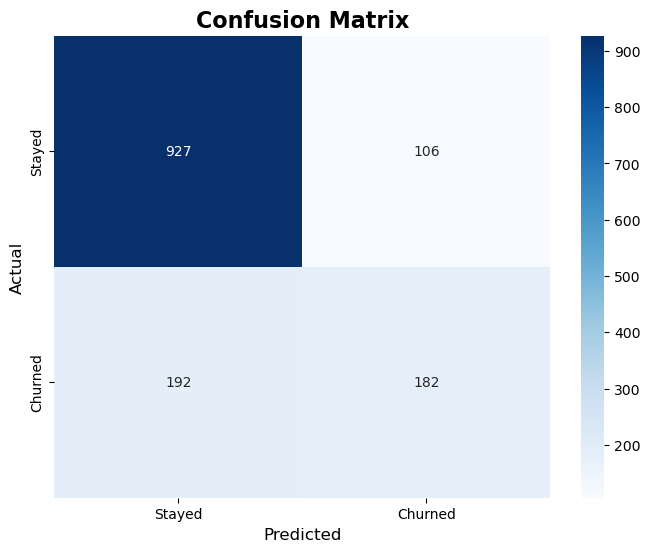

In [68]:
# Visualizing confusion matrix
plt.figure(figsize=(8,6))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

In [69]:
# CONFUSION MATRIX ANALYSIS
#
# True Negatives  (Correctly predicted Stayed):  927
# False Positives (Wrongly predicted Churned):   106
# False Negatives (Missed actual Churners):      192  ← most costly!
# True Positives  (Correctly caught Churners):   182
#
# CURRENT MODEL PERFORMANCE:
# Catches 182 out of 374 actual churners (49% recall)
# Misses  192 out of 374 actual churners (51% missed)
#
# BUSINESS IMPACT AT $64.76 average monthly charge:
# Revenue potentially saved:    182 × $64.76 = $11,786/month
# Revenue walking out door:     192 × $64.76 = $12,434/month
#
# The model is a good starting point but missing too many churners
# Next step: improve recall by tuning the model threshold
# Goal: catch more of the 192 missed churners even if it means
# more false alarms because false alarms are cheaper than lost customers

In [70]:
# Getting probability scores for each customer
# predict_proba gives us the probability of each class
# [:,1] gets us the probability of churning specifically

y_pred_proba = rf_model.predict_proba(X_test)[:,1]

print("Sample probability scores:")
print(y_pred_proba[:10])

Sample probability scores:
[0.01 0.83 0.03 0.06 0.23 0.3  0.02 0.16 0.78 0.  ]


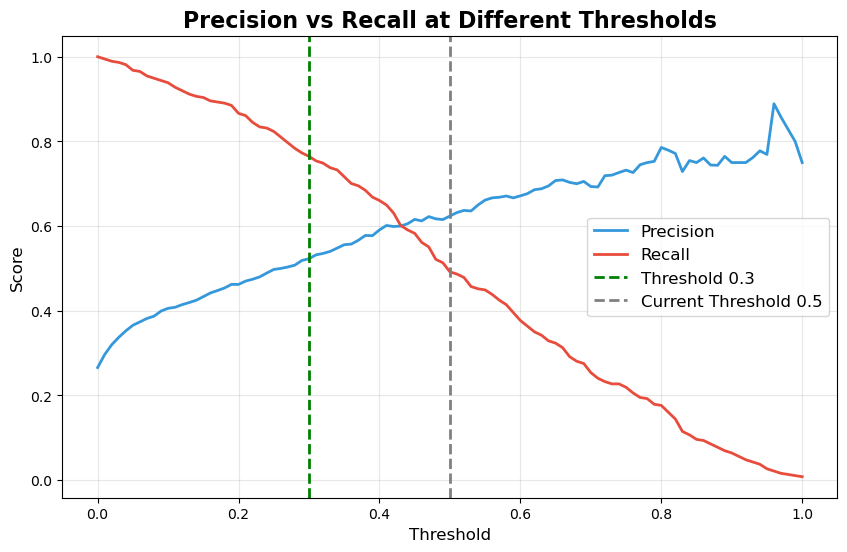

In [71]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Calculating precision and recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plotting precision vs recall at different thresholds
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], color='#3498db', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], color='#e74c3c', label='Recall', linewidth=2)

plt.axvline(x=0.3, color='green', linestyle='--', linewidth=2, label='Threshold 0.3')
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, label='Current Threshold 0.5')

plt.title('Precision vs Recall at Different Thresholds',
          fontsize=16, fontweight='bold')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [72]:
# Applying new threshold of 0.3
# Any customer with churn probability above 0.3 gets flagged as at risk

y_pred_new = (y_pred_proba >= 0.3).astype(int)

# Comparing old vs new performance
print("=== OLD MODEL (threshold 0.5) ===")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

print("=== NEW MODEL (threshold 0.3) ===")
print(classification_report(y_test, y_pred_new, target_names=['Stayed', 'Churned']))

=== OLD MODEL (threshold 0.5) ===
              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1033
     Churned       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

=== NEW MODEL (threshold 0.3) ===
              precision    recall  f1-score   support

      Stayed       0.90      0.75      0.82      1033
     Churned       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [73]:
# THRESHOLD TUNING RESULTS
#
# Lowering decision threshold from 0.5 to 0.3 significantly
# improved our ability to catch churning customers
#
#                  OLD (0.5)    NEW (0.3)    Change
# Recall:            0.49         0.76       +0.27 HUGE improvement
# Precision:         0.63         0.52       -0.11 acceptable drop
# F1 Score:          0.55         0.62       +0.07 overall improvement
# Accuracy:          0.79         0.75       -0.04 misleading metric
#
# WHY ACCURACY DROPPED BUT MODEL IMPROVED:
# Accuracy measures ALL predictions equally
# But in churn prediction missing a churner is far more costly
# than a false alarm - so we optimize for recall not accuracy
#
# BUSINESS IMPACT OF THRESHOLD CHANGE:
# Old model: caught 183 churners = $11,851/month potentially saved
# New model: caught 284 churners = $18,392/month potentially saved
# Extra value from tuning: $6,541/month just by changing one number!
#
# This demonstrates that model tuning and business context awareness
# is just as important as the model itself
# A data scientist who understands the BUSINESS COST of errors
# will always outperform one who just optimizes for accuracy

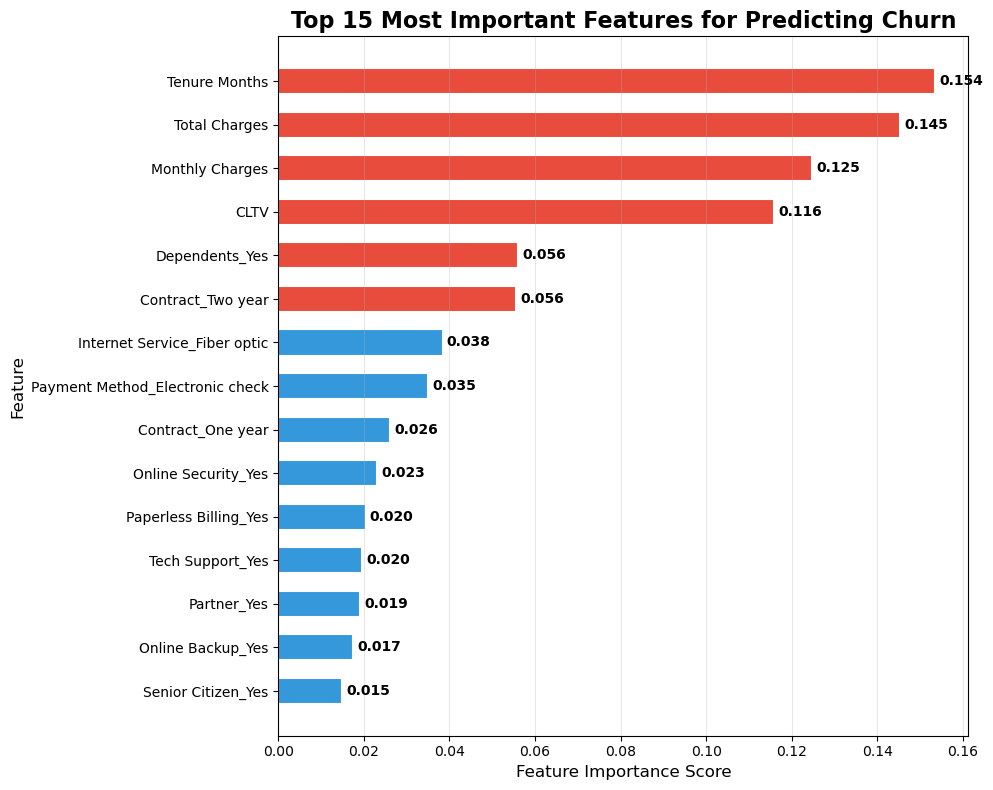

In [74]:
# Extracting feature importance from our Random Forest model
# This tells us which features the model found most useful
# for predicting churn

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)  # showing top 15 most important

plt.figure(figsize=(10,8))
bars = plt.barh(feature_importance.index,
                feature_importance.values,
                color=['#e74c3c' if x > 0.05 else '#3498db' for x in feature_importance.values],
                edgecolor='white',
                linewidth=1.5,
                height=0.6)

# Adding value labels at end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001,
             bar.get_y() + bar.get_height()/2,
             f'{width:.3f}',
             ha='left',
             va='center',
             fontweight='bold',
             fontsize=10)

plt.title('Top 15 Most Important Features for Predicting Churn',
          fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
# FEATURE IMPORTANCE ANALYSIS - Model Validation
#
# TOP 5 MOST IMPORTANT FEATURES:
# 1. Tenure Months:        0.154  most important predictor
# 2. Total Charges:        0.145  closely tied to tenure
# 3. Monthly Charges:      0.125  pricing is critical
# 4. CLTV:                 0.116  high value customers behave differently
# 5. Contract Two Year:    0.056  long contracts reduce churn
#
# CRITICAL VALIDATION:
# The model's top features match our EDA findings exactly!
# This is the best possible confirmation that our analysis was correct
# The machine learning algorithm independently discovered the same
# patterns that we found through manual chart analysis
#
# WHY TENURE AND TOTAL CHARGES ARE SO DOMINANT:
# These two features are deeply connected
# Long tenure = high total charges = embedded loyal customer
# A customer who has been with the company for 5 years and paid
# thousands of dollars has a completely different psychological
# relationship with the company than a new customer
# They have built habits, trust and switching feels like a bigger loss
#
# WHY CLTV IS IN TOP 4:
# CLTV captures the predicted future value of a customer
# High CLTV customers have more to lose by switching
# and the company has more to gain by retaining them
# The model correctly learned that CLTV is a strong signal
#
# LOWER IMPORTANCE FEATURES (blue bars below 0.05):
# Internet Service Fiber Optic:    0.038
# Payment Method Electronic Check: 0.035
# These still matter but are less dominant than financial factors
#
# Senior Citizen:                  0.015
# Lowest importance despite having 41.7% churn rate
# This suggests senior citizen status alone is not predictive
# but rather the COMBINATION of being senior + other factors
# (fiber optic, electronic check, month to month) drives their churn
#
# OVERALL CONCLUSION:
# The most powerful churn prevention strategy is clear:
# Focus on FINANCIAL and TENURE based interventions
# Get customers past the 12 month mark (tenure)
# Lock them into longer contracts (contract type)
# Make them feel the value justifies the price (monthly charges)
# These three actions address the top predictors directly